# MAI Dissertation Notebook

## Privacy-Preserving Outbreak Surveillance with Geospatially-Aware Machine Learning

This notebook implements the experimental workflow for the dissertation project on privacy-preserving outbreak surveillance. The core idea is to combine differential privacy with geospatially-aware machine learning so outbreak signals can be shared for analysis while reducing the risk of exposing sensitive patient information.

The workflow starts from real COVID-19 case data, builds an Asia-focused outbreak detection pipeline, measures false positives and threshold behaviour, and then evaluates whether a cost-sensitive post-processing model can recover utility after privacy noise is added.

The sections below explain each stage of the pipeline without changing the original code comments already included in the notebook.


In [1]:
#Final Draft

## 1. Environment Setup and Imports

This section loads the scientific Python stack used throughout the analysis. The imported libraries support data wrangling, visualisation, robust outbreak thresholding, and the gradient boosting model used later for privacy-aware post-processing.


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import median_abs_deviation
from sklearn.metrics import roc_curve, auc

## 2. Data Loading, Cleaning, and Regional Preparation

Here the notebook loads the OWID COVID-19 dataset from Kaggle, defines the Laplace mechanism used for differential privacy, and prepares the data for regional analysis. The preprocessing step also isolates Asian countries and creates a population-based weight, which is later used in the cost-sensitive penalty design.


In [2]:
# Step 1: Load raw COVID-19 data
data = pd.read_csv('/kaggle/input/covid19/owid-covid-data.csv')

# Step 2: Define DP function
def apply_laplace_dp(true_count, sensitivity, epsilon):
    """Apply Laplace mechanism to case counts"""
    noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
    return max(0, true_count + noise)

# Step 3: Sort data according to continent and then date
data = data.sort_values(by=['continent', 'date']).reset_index(drop=True)

# Step 4: Remove NaN values from data to avoid computational errors
numeric_cols = ['new_cases', 'population']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col] = np.where(np.isfinite(data[col]), data[col], 0)

# Step 5: Normalize weights for population in Asia 
asia_data = data[data['continent'] == 'Asia'].copy()
asia_unique = (asia_data.groupby('location', as_index=False)['population'].max())
asia_total_pop = asia_unique['population'].sum()
asia_data['pop_weight'] = asia_data['population'] / asia_total_pop

## 3. Global Coverage Map

This visualisation gives a quick geographic overview of countries that report at least one non-zero COVID-19 case in the dataset. It acts as a sanity check on global coverage before the notebook narrows the analysis to Asia.


In [4]:
import pandas as pd
import plotly.express as px

# Ensure 'date' column is datetime
data['date'] = pd.to_datetime(data['date'])

# Filter rows where new_cases > 0
cases_data = data[data['new_cases'] > 0].copy()

# Keep only one row per country (one marker per country)
cases_data = cases_data.groupby('iso_code', as_index=False).first()

# Create scatter_geo map with small pin markers
fig = px.scatter_geo(
    cases_data,
    locations="iso_code",
    hover_name="location",
    size=[1]*len(cases_data),       # small fixed marker
    projection="natural earth",
    title="Countries with at least 1 new COVID-19 case"
)

# Optional: make markers look more like pins
fig.update_traces(marker=dict(
    size=5,            # small size
    symbol="circle",   # pin-like marker
    color="red",       # marker color
    line=dict(width=0) # no border
))

fig.show()

## 4. Exploratory Time-Series View for Asia

The quarterly line plots provide an initial view of how reported case counts evolve over time within the Asian subset. This exploratory step helps motivate the need for dynamic thresholds rather than relying on a single fixed outbreak rule.


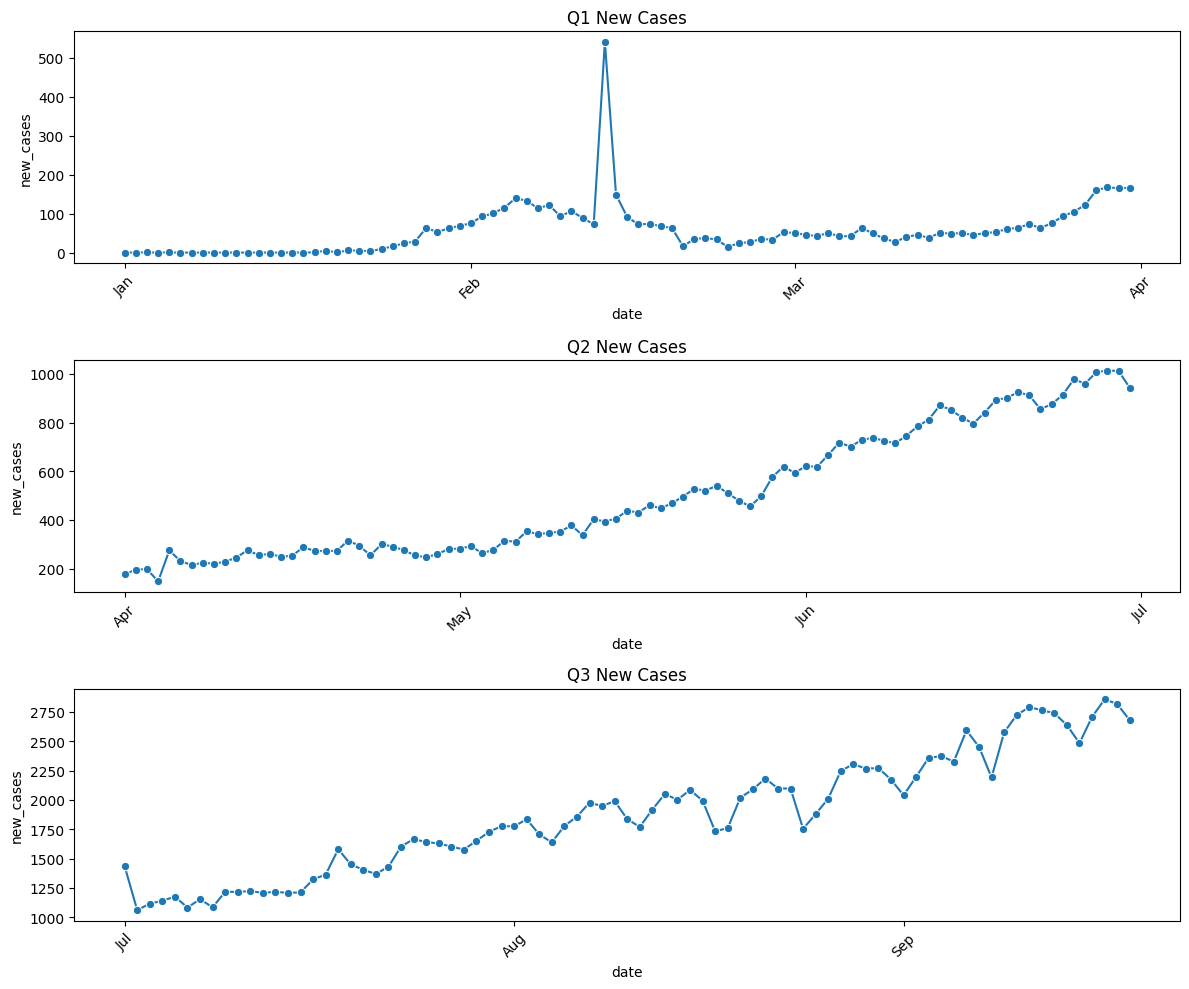

In [5]:
# Plot line graph for new_cases vs date for different quarters

# Convert dates and clean
asia_data["date"] = pd.to_datetime(asia_data["date"])

# Define quarters
quarters = [1, 2, 3]
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes = axes.ravel() 

for i, q in enumerate(quarters):
    q_data = asia_data[asia_data["date"].dt.quarter == q]
    
    if not q_data.empty:
        ax = sns.lineplot(data=q_data, x="date", y="new_cases", ax=axes[i], errorbar=None, marker='o')
        ax.set_title(f"Q{q} New Cases")
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', rotation=45)
    else:
        axes[i].text(0.5, 0.5, f'No data for Q{q}', ha='center', va='center', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()

## 5. Baseline Outbreak Detection Logic

This section constructs the baseline outbreak label using a rolling historical baseline, a robust median absolute deviation estimate, short-term growth behaviour, and a persistence requirement. Together, these signals are used to define whether a country-day should be treated as a confirmed outbreak event and to generate a seven-day-ahead reference label for evaluation.


In [3]:
# Step 6: Define the threshold dynamically 

# Constants
BASELINE_WINDOW = 21   # 21-day lookback window
Z_THRESH = 2.30        # 2.30 standard deviations above baseline = anomaly
MIN_PERSISTENCE = 3    # anomaly must persist for 3+ consecutive days

# Define the new normal during the outbreak
asia_data['rolling_mean'] = (asia_data.groupby('iso_code')['new_cases'].transform(lambda x: x.rolling(BASELINE_WINDOW).mean()))

# Robust measure of spread
asia_data['rolling_mad'] = (asia_data.groupby('iso_code')['new_cases'].transform(lambda x: x.rolling(BASELINE_WINDOW).apply(lambda v: median_abs_deviation(v, scale='normal'), raw=True)))
asia_data['rolling_mad'] = asia_data['rolling_mad'].replace(0, np.nan)

# Observe daily exponential growth over the past week
asia_data['log_cases'] = np.log1p(asia_data['new_cases'])
asia_data['growth_rate'] = (asia_data.groupby('iso_code')['log_cases'].transform(lambda x: x.diff(7) / 7))
asia_data['z_score'] = ((asia_data['new_cases'] - asia_data['rolling_mean']) /asia_data['rolling_mad'])

# 3 flags defined to detect outbreak
asia_data['magnitude_flag'] = asia_data['z_score'] > Z_THRESH
asia_data['growth_flag'] = asia_data['growth_rate'] > 0.05
asia_data['persistent_flag'] = (asia_data.groupby('iso_code')['magnitude_flag'].transform(lambda x: x.rolling(MIN_PERSISTENCE).sum() >= MIN_PERSISTENCE))

# Confirm whether it is an outbreak or not
asia_data['confirmed_outbreak'] = (asia_data['magnitude_flag'] & asia_data['growth_flag'] & asia_data['persistent_flag']).astype(int)
asia_data['confirmed_outbreak_t_plus_7'] = (asia_data.groupby('iso_code')['confirmed_outbreak'].shift(-7).fillna(0).astype(int))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 6. False Positive Rate Analysis

Once the baseline labels are available, the notebook measures how often the thresholding rule raises an outbreak flag that is not followed by a confirmed outbreak seven days later. Plotting the false positive rate over time is important because the dissertation focuses on reducing unreliable signals, especially in settings where noisy surveillance data could mislead downstream decisions.


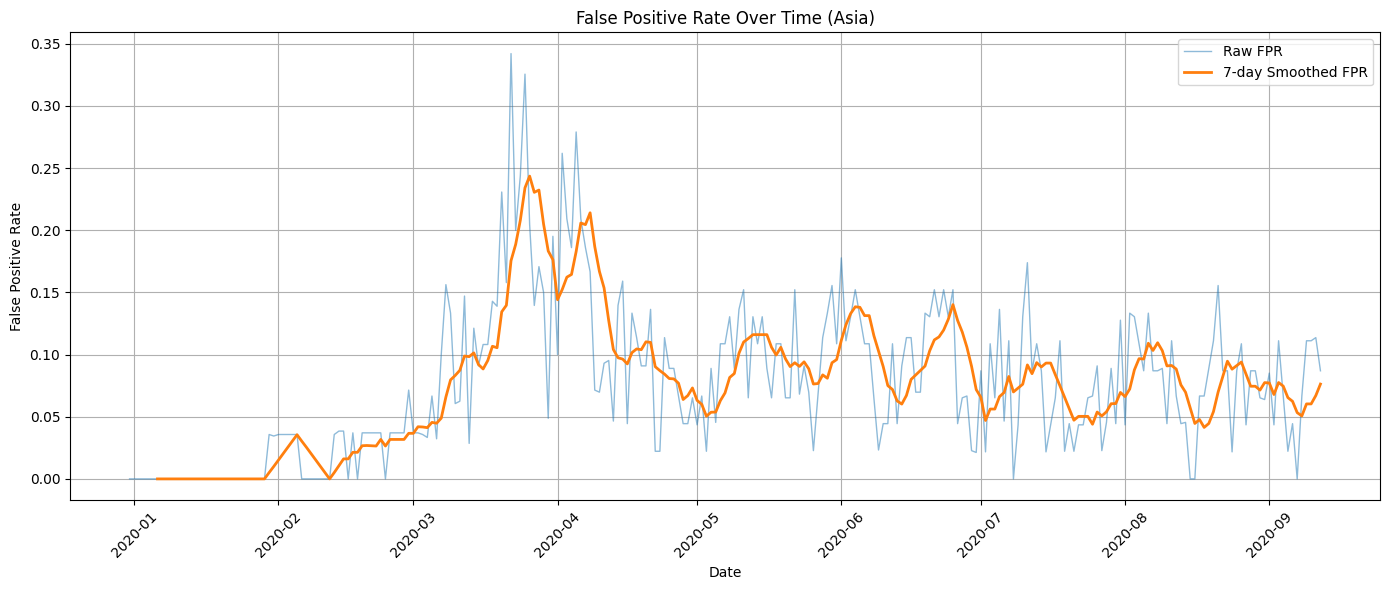

In [4]:
# Step 7: Draw a FPR plot over time

# Remove last 7 rows from the data
valid_mask = asia_data.groupby('iso_code').cumcount(ascending=False) >= 7
asia_data_eval = asia_data[valid_mask].copy()

# Find False positves and Actual Negatives
asia_data_eval['predicted_flag'] = (asia_data_eval['z_score'] > Z_THRESH).astype(int)
asia_data_eval['false_positive'] = ((asia_data_eval['predicted_flag'] == 1) & (asia_data_eval['confirmed_outbreak_t_plus_7'] == 0)).astype(int)
asia_data_eval['actual_negative'] = (asia_data_eval['confirmed_outbreak_t_plus_7'] == 0).astype(int)

# Compute FPR over time
fpr_by_date = (asia_data_eval.groupby('date').agg(fp=('false_positive', 'sum'), actual_neg=('actual_negative', 'sum')).reset_index())
fpr_by_date['fp_rate'] = np.where(fpr_by_date['actual_neg'] > 0,fpr_by_date['fp'] / fpr_by_date['actual_neg'],np.nan)
fpr_by_date['date'] = pd.to_datetime(fpr_by_date['date'])
fpr_by_date['fp_rate_smooth'] = fpr_by_date['fp_rate'].rolling(7).mean()

plt.figure(figsize=(14, 6))
plt.plot(fpr_by_date['date'], fpr_by_date['fp_rate'], alpha=0.5, linewidth=1, label='Raw FPR')
plt.plot(fpr_by_date['date'], fpr_by_date['fp_rate_smooth'], linewidth=2, label='7-day Smoothed FPR')
plt.legend()
plt.xlabel("Date")
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate Over Time (Asia)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. ROC Analysis and Threshold Calibration

This block evaluates the continuous outbreak score against the future outbreak label using an ROC curve. The aim is to understand the discrimination power of the score and to estimate a useful operating threshold using Youden's Index before privacy-preserving experiments are introduced.


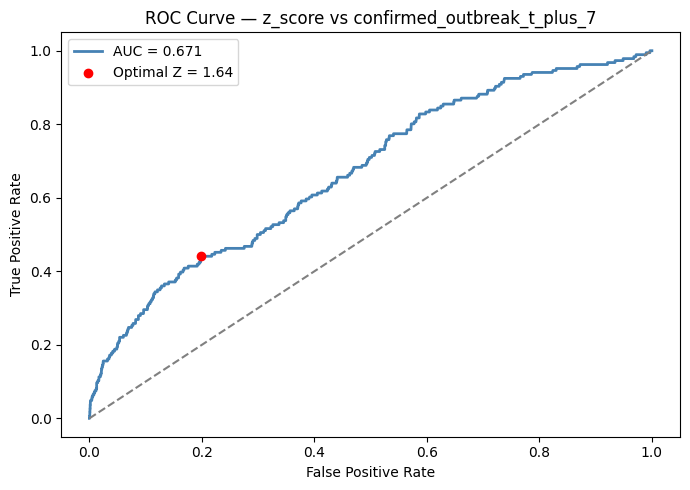

AUC:               0.671
Optimal Z_THRESH:  1.64  (Youden's J = 0.242)
TPR at optimal:    0.441
FPR at optimal:    0.199


In [5]:
# Step 8: Plot ROC curve

# ROC curve (z_score vs t+7 ground truth)
mask = np.isfinite(asia_data_eval['confirmed_outbreak_t_plus_7']) & np.isfinite(asia_data_eval['z_score'])
y_true = asia_data_eval.loc[mask, 'confirmed_outbreak_t_plus_7']
y_score= asia_data_eval.loc[mask, 'z_score']

fpr_roc, tpr_roc, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr_roc, tpr_roc)

# Optimal threshold via Youden's Index
youden_j = tpr_roc - fpr_roc
optimal_idx = np.argmax(youden_j)
optimal_z = thresholds[optimal_idx]

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_roc, tpr_roc, color='steelblue', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.scatter(fpr_roc[optimal_idx], tpr_roc[optimal_idx], color='red', zorder=5, label=f"Optimal Z = {optimal_z:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — z_score vs confirmed_outbreak_t_plus_7")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC:               {roc_auc:.3f}")
print(f"Optimal Z_THRESH:  {optimal_z:.2f}  (Youden's J = {youden_j[optimal_idx]:.3f})")
print(f"TPR at optimal:    {tpr_roc[optimal_idx]:.3f}")
print(f"FPR at optimal:    {fpr_roc[optimal_idx]:.3f}")

## 8. Geospatial Penalty Design and ML Post-Processing

The dissertation proposes a cost-sensitive post-processing stage that takes geospatial context into account. The penalty function combines population sensitivity and recent false positive behaviour so regions that are more privacy-sensitive or more error-prone can be treated more carefully. The helper function defined here prepares the machine learning correction step that is applied after differential privacy noise has been added.


In [6]:
# Step 9: Penalty function for cost-sensitive learning
def calculate_region_penalty(row, alpha_pop=5.0, beta_fp=9.0, max_penalty=10.0):
    # Population term (concave so very large countries don't dominate)
    pop_w = row.get('pop_weight')
    pop_w = float(pop_w)
    pop_term = 1.0 + alpha_pop * np.sqrt(pop_w)

    # Historical false-positive term (higher FP rate → stronger penalty)
    fp_rate = float(row.get('recent_fp_rate', 0.0) or 0.0)
    fp_term = 1.0 + beta_fp * fp_rate

    # Combined penalty with a hard cap for stability/DP-sensitivity
    penalty = pop_term * fp_term
    return min(penalty, max_penalty)
    
# Step 10: ML post-processing function
FEATURES = [
    'dp_confirmed_outbreak',
    'dp_z_score',
    'dp_growth_rate',
    'dp_rolling_mean',
    'dp_rolling_mad',
    'surge_ratio',
    'days_since_outbreak'
]

def ml_post_processing(dp_data, model, imputer, threshold):
    X = imputer.transform(dp_data[FEATURES].copy())
    outbreak_prob = model.predict_proba(X)[:, 1]
    dp_data['ml_corrected_outbreak'] = (outbreak_prob >= threshold).astype(int)
    return dp_data

## 9. Main Differential Privacy Experiment

This is the core experiment loop. For each privacy budget value, the notebook perturbs daily case counts with Laplace noise, rebuilds privacy-aware outbreak features, applies the regional penalty scheme, trains a gradient boosting classifier on time-based splits, and compares the baseline differentially private outbreak signal with the ML-corrected version using F1 score.


In [23]:
# Step 11: Main experiment loop - Apply DP once per epsilon (Asia only)
epsilon_values = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0]
results = []

for eps in epsilon_values:

    print(f"\nProcessing epsilon = {eps}")
    asia_eps = asia_data.copy()
    
    # Ensure consistent ordering before any rolling calculations
    asia_eps['date'] = pd.to_datetime(asia_eps['date'])
    asia_eps = asia_eps.sort_values(['iso_code', 'date'])

    # DP-noisy case counts
    asia_eps['dp_case_count'] = asia_eps['new_cases'].apply(lambda x: apply_laplace_dp(x, sensitivity=1, epsilon=eps))

    # ----- Dynamic outbreak detection on DP counts (Step 6) -----
    # Define the new normal during the outbreak
    asia_eps['dp_rolling_mean'] = (asia_eps.groupby('iso_code')['dp_case_count'].transform(lambda x: x.rolling(BASELINE_WINDOW).mean()))

    # Robust measure of spread
    asia_eps['dp_rolling_mad'] = (asia_eps.groupby('iso_code')['dp_case_count'].transform(lambda x: x.rolling(BASELINE_WINDOW).apply(lambda v: median_abs_deviation(v, scale='normal'),raw=True)))
    asia_eps['dp_rolling_mad'] = asia_eps['dp_rolling_mad'].replace(0, np.nan)

    # Observe daily exponential growth over the past week
    asia_eps['dp_log_cases'] = np.log1p(asia_eps['dp_case_count'])
    asia_eps['dp_growth_rate'] = (asia_eps.groupby('iso_code')['dp_log_cases'].transform(lambda x: x.diff(7) / 7))
    asia_eps['dp_z_score'] = ((asia_eps['dp_case_count'] - asia_eps['dp_rolling_mean']) /asia_eps['dp_rolling_mad'])

    # 3 flags defined to detect outbreak
    asia_eps['dp_magnitude_flag'] = asia_eps['dp_z_score'] > 1.64
    asia_eps['dp_growth_flag'] = asia_eps['dp_growth_rate'] > 0.05
    asia_eps['dp_persistent_flag'] = (asia_eps.groupby('iso_code')['dp_magnitude_flag'].transform(lambda x: x.rolling(MIN_PERSISTENCE).sum() >= MIN_PERSISTENCE))

    # Confirm whether it is an outbreak or not
    asia_eps['dp_confirmed_outbreak'] = (asia_eps['dp_magnitude_flag'] & asia_eps['dp_growth_flag'] & asia_eps['dp_persistent_flag']).astype(int)

    # Derived features (days since outbreak lasting/previous outbreak occured & its magnitude)
    asia_eps['days_since_outbreak'] = (asia_eps.groupby('iso_code')['dp_confirmed_outbreak'].transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumcount()))
    asia_eps['surge_ratio'] = (asia_eps['dp_case_count'] /asia_eps['dp_rolling_mean'].replace(0, np.nan)).fillna(1.0).clip(0, 10)
    
    # False positives/True positives
    asia_eps['false_positive'] = ((asia_eps['dp_confirmed_outbreak'] == 1) & (asia_eps['confirmed_outbreak_t_plus_7'] == 0)).astype(int)
    asia_eps['true_positive'] = ((asia_eps['dp_confirmed_outbreak'] == 1) & (asia_eps['confirmed_outbreak_t_plus_7'] == 1)).astype(int)

    # Per-region recent FP rate
    asia_eps['recent_fp_rate'] = (asia_eps.groupby('iso_code')['false_positive'].transform(lambda s: s.rolling(28,min_periods=7).mean()).fillna(0.0).clip(0.0, 1.0))

    # Data 60/20/20 time-based split
    unique_dates = asia_eps['date'].sort_values().unique()
    train_cutoff = unique_dates[int(len(unique_dates) * 0.60)]
    val_cutoff = unique_dates[int(len(unique_dates) * 0.80)]
    train_mask = asia_eps['date'] < train_cutoff
    val_mask = (asia_eps['date'] >= train_cutoff) & (asia_eps['date'] < val_cutoff)
    test_mask = asia_eps['date'] >= val_cutoff

    last_train_fp = asia_eps.loc[train_mask].groupby('iso_code')['recent_fp_rate'].last()
    for iso in asia_eps['iso_code'].unique():
        idx = asia_eps[(asia_eps['iso_code'] == iso) & (val_mask | test_mask)].index
        asia_eps.loc[idx, 'recent_fp_rate'] = last_train_fp.get(iso, 0.0)
    asia_eps['recent_fp_rate'] = asia_eps['recent_fp_rate'].fillna(0.0).clip(0.0, 1.0)

    # Cost-sensitive weights (applying weight penalty)
    asia_eps['fp_penalty'] = asia_eps.apply(calculate_region_penalty, axis=1)
    asia_eps['sample_weight'] = 1.0 
    asia_eps.loc[asia_eps['false_positive'] == 1, 'sample_weight'] = asia_eps.loc[asia_eps['false_positive'] == 1, 'fp_penalty']

    # Train / val / test matrices
    X_train = asia_eps.loc[train_mask, FEATURES].copy()
    y_train = asia_eps.loc[train_mask, 'confirmed_outbreak'].astype(int)
    X_val = asia_eps.loc[val_mask, FEATURES].copy()
    y_val = asia_eps.loc[val_mask, 'confirmed_outbreak'].astype(int)
    X_test = asia_eps.loc[test_mask, FEATURES].copy()
    y_test = asia_eps.loc[test_mask, 'confirmed_outbreak'].astype(int)

    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    X_val_imputed = imputer.transform(X_val)
    X_test_imputed = imputer.transform(X_test)

    # Class balancing
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    balance_ratio = n_neg / n_pos if n_pos > 0 else 1.0
    raw_weights = np.nan_to_num(asia_eps.loc[train_mask, 'sample_weight'].values, nan=1.0).astype(float)
    balanced_weights = raw_weights.copy()
    balanced_weights[y_train == 1] *= balance_ratio

    # Train model
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42
    )
    model.fit(X_train_imputed, y_train, sample_weight=balanced_weights)
    
    # Val-optimised threshold
    val_probs = model.predict_proba(X_val_imputed)[:, 1]
    optimal_thresh = max(((t, f1_score(y_val, (val_probs >= t).astype(int), zero_division=0)) for t in np.arange(0.05, 0.95, 0.01)), key=lambda x: x[1])[0]

    # Evaluation
    baseline_f1 = f1_score(y_test, asia_eps.loc[test_mask, 'dp_confirmed_outbreak'].astype(int))
    asia_corrected = ml_post_processing(asia_eps[test_mask].copy(), model, imputer, optimal_thresh)
    ml_f1 = f1_score(y_test, asia_corrected['ml_corrected_outbreak'])

    # Store ROC data for plotting
    roc_mask = np.isfinite(asia_eps.loc[test_mask, 'confirmed_outbreak_t_plus_7']) & np.isfinite(asia_eps.loc[test_mask, 'dp_z_score'])
    roc_store = {'y_true': y_test.values, 'dp_z_score': asia_eps.loc[test_mask, 'dp_z_score'].values}
    
    results.append({
        'epsilon': eps,
        'baseline_f1': baseline_f1,
        'ml_corrected_f1': ml_f1,
        'improvement': ml_f1 - baseline_f1,
        'roc_data': roc_store})

    print(f"Baseline F1={baseline_f1:.4f}  ML-corrected F1={ml_f1:.4f} Difference={ml_f1 - baseline_f1:+.4f}")
    train_preds = model.predict(X_train_imputed)
    train_f1 = f1_score(y_train, train_preds)
    val_preds = (val_probs >= optimal_thresh).astype(int)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)
    
    print(f"  Train F1={train_f1:.4f}  Val F1={val_f1:.4f}  Test F1={ml_f1:.4f}")


Processing epsilon = 0.1
Baseline F1=0.5116  ML-corrected F1=0.5217 Difference=+0.0101
  Train F1=0.4385  Val F1=0.5385  Test F1=0.5217

Processing epsilon = 0.5
Baseline F1=0.7255  ML-corrected F1=0.7895 Difference=+0.0640
  Train F1=0.7186  Val F1=0.7250  Test F1=0.7895

Processing epsilon = 1.0
Baseline F1=0.6667  ML-corrected F1=0.7632 Difference=+0.0965
  Train F1=0.7652  Val F1=0.7356  Test F1=0.7632

Processing epsilon = 2.0
Baseline F1=0.7525  ML-corrected F1=0.7949 Difference=+0.0424
  Train F1=0.8169  Val F1=0.7209  Test F1=0.7949

Processing epsilon = 3.0
Baseline F1=0.7835  ML-corrected F1=0.8205 Difference=+0.0370
  Train F1=0.7923  Val F1=0.7407  Test F1=0.8205

Processing epsilon = 4.0
Baseline F1=0.7525  ML-corrected F1=0.8052 Difference=+0.0527
  Train F1=0.8011  Val F1=0.7143  Test F1=0.8052


## 10. ROC Curves Across Privacy Budgets

After running the experiment, this section compares ROC behaviour across different epsilon values. It helps show how separability changes as the privacy budget becomes more or less restrictive and provides another lens on the privacy-utility trade-off explored in the dissertation.


ε=0.1   AUC=0.861  Opt Z=1.64  J=0.647  TPR=0.789  FPR=0.142
ε=0.5   AUC=0.968  Opt Z=2.39  J=0.898  TPR=0.974  FPR=0.076
ε=1.0   AUC=0.962  Opt Z=2.32  J=0.871  TPR=0.947  FPR=0.077
ε=2.0   AUC=0.969  Opt Z=2.54  J=0.879  TPR=0.947  FPR=0.068
ε=3.0   AUC=0.968  Opt Z=2.21  J=0.915  TPR=1.000  FPR=0.085
ε=4.0   AUC=0.970  Opt Z=2.21  J=0.915  TPR=1.000  FPR=0.085


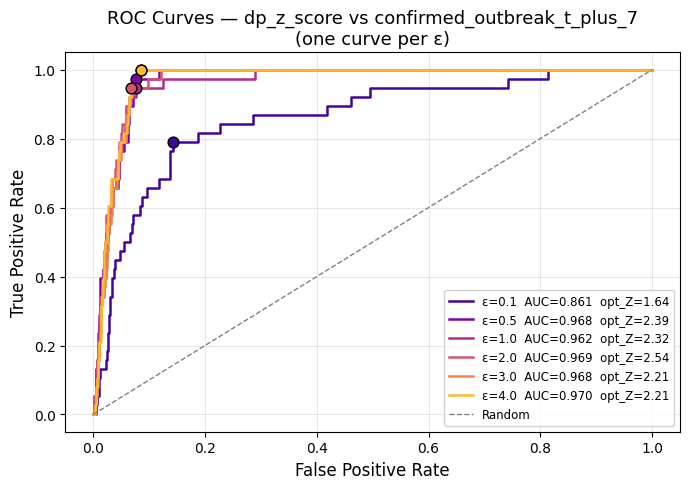

In [24]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(7, 5))
colors = cm.plasma(np.linspace(0.1, 0.85, len(results)))

for res, color in zip(results, colors):
    eps     = res['epsilon']
    y_true  = res['roc_data']['y_true']
    y_score = res['roc_data']['dp_z_score']

    mask = np.isfinite(y_true) & np.isfinite(y_score)
    y_true  = y_true[mask]
    y_score = y_score[mask]

    fpr_roc, tpr_roc, thresholds = roc_curve(y_true, y_score)
    roc_auc  = auc(fpr_roc, tpr_roc)
    youden_j = tpr_roc - fpr_roc
    opt_idx  = np.argmax(youden_j)
    optimal_z = thresholds[opt_idx]

    ax.plot(fpr_roc, tpr_roc, color=color, lw=1.8,
            label=f"ε={eps}  AUC={roc_auc:.3f}  opt_Z={optimal_z:.2f}")
    ax.scatter(fpr_roc[opt_idx], tpr_roc[opt_idx],
               color=color, edgecolors='black', zorder=5, s=60)

    print(f"ε={eps:<4}  AUC={roc_auc:.3f}  Opt Z={optimal_z:.2f}  "
          f"J={youden_j[opt_idx]:.3f}  TPR={tpr_roc[opt_idx]:.3f}  "
          f"FPR={fpr_roc[opt_idx]:.3f}")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — dp_z_score vs confirmed_outbreak_t_plus_7\n(one curve per ε)", fontsize=13)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Class Balance Check

This short diagnostic reports the prevalence of outbreak versus non-outbreak rows in the Asia dataset. It gives context for the class imbalance handled during model training and helps explain why weighted learning is useful in this setting.


In [25]:
# Overall prevalence in full Asia dataset
total_rows     = len(asia_data)
total_outbreaks = asia_data['confirmed_outbreak'].sum()
prevalence     = total_outbreaks / total_rows * 100

print(f"Total rows:              {total_rows}")
print(f"Outbreak rows (1):       {total_outbreaks}")
print(f"Non-outbreak rows (0):   {total_rows - total_outbreaks}")
print(f"Prevalence:              {prevalence:.2f}%")

Total rows:              10757
Outbreak rows (1):       220
Non-outbreak rows (0):   10537
Prevalence:              2.05%


## 12. Sensitivity Analysis for Penalty Parameters

The next plot compares F1 gains under several combinations of the population-sensitivity and false-positive penalty parameters. This supports the dissertation's investigation into how the proposed cost-sensitive design affects downstream utility under different privacy budgets.


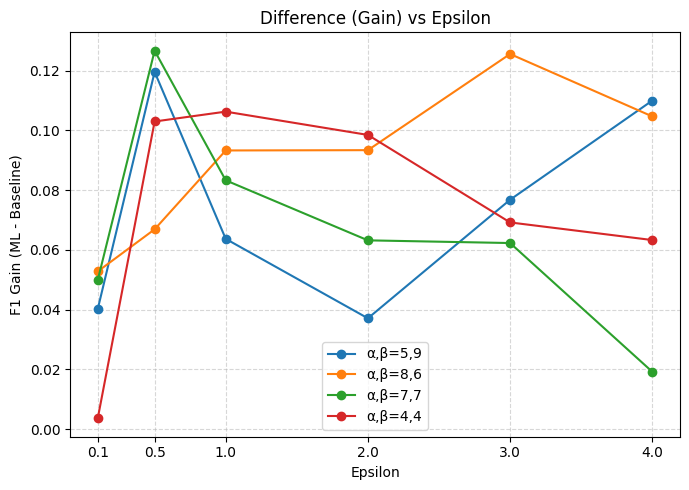

In [26]:
import matplotlib.pyplot as plt

# Epsilon values
eps = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0]

# Updated difference (ML - Baseline) data
diff_data = {
    "5,9": [0.0402, 0.1196, 0.0637, 0.0371, 0.0768, 0.1100],
    "8,6": [0.0528, 0.0669, 0.0933, 0.0934, 0.1256, 0.1047],
    "7,7": [0.0499, 0.1267, 0.0833, 0.0632, 0.0623, 0.0192],
    "4,4": [0.0036, 0.1030, 0.1063, 0.0985, 0.0692, 0.0633],
}

plt.figure(figsize=(7,5))
for k, v in diff_data.items():
    plt.plot(eps, v, marker='o', label=f"α,β={k}")

plt.xlabel("Epsilon")
plt.ylabel("F1 Gain (ML - Baseline)")
plt.title("Difference (Gain) vs Epsilon")
plt.xticks(eps)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Final Performance Comparison Plots

The closing figures summarise train, validation, and test behaviour together with the baseline and ML-corrected F1 scores. These plots provide the main performance view for discussing whether the geospatially-aware post-processing framework improves utility while preserving stronger privacy guarantees.


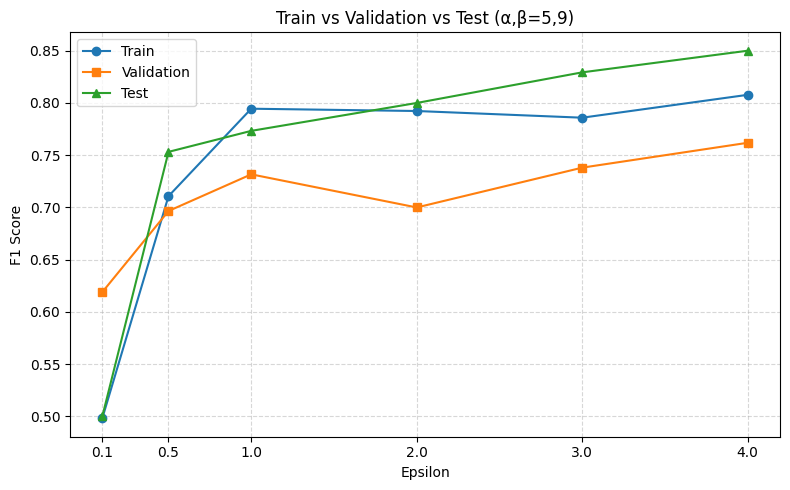

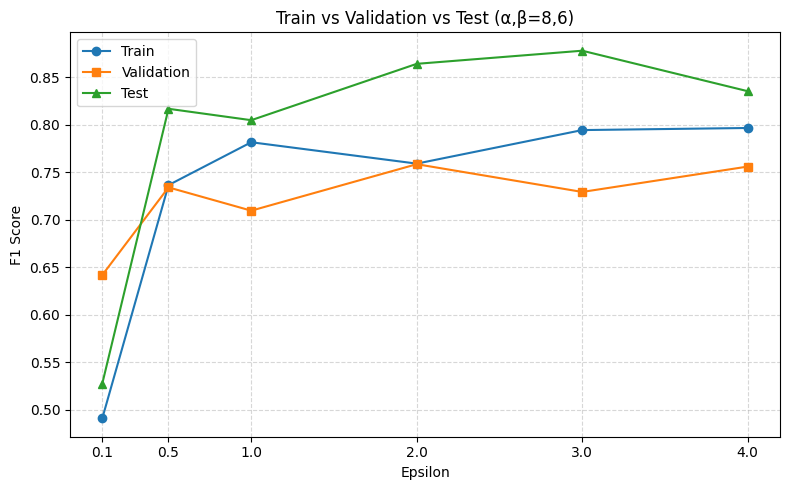

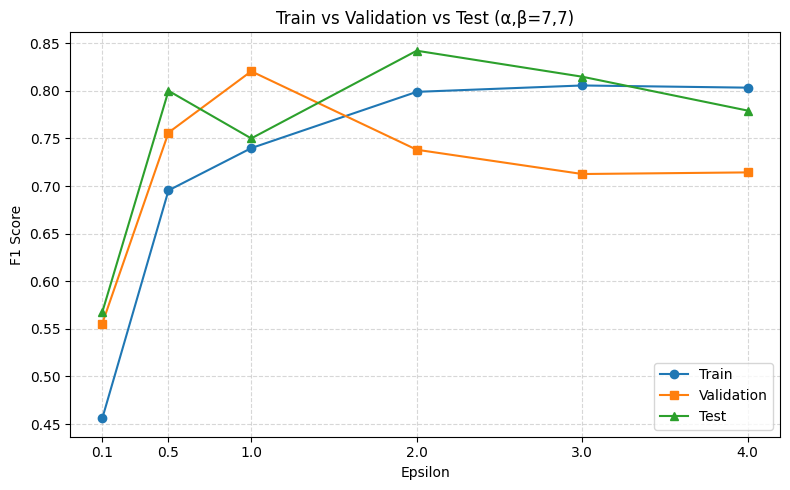

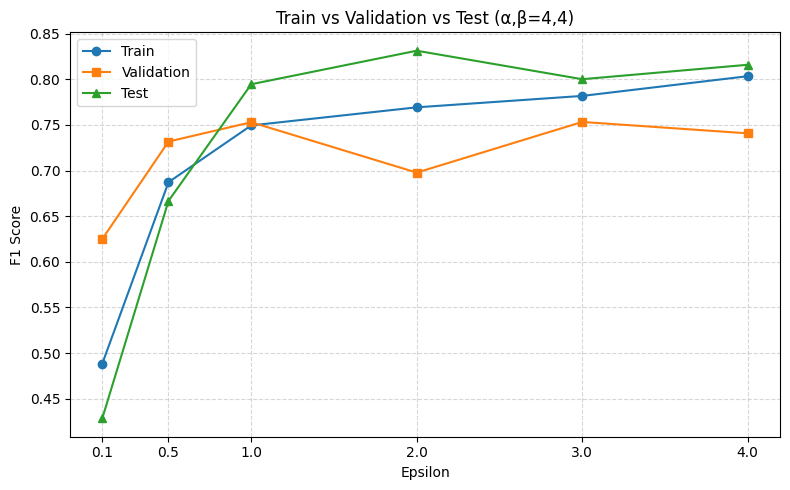

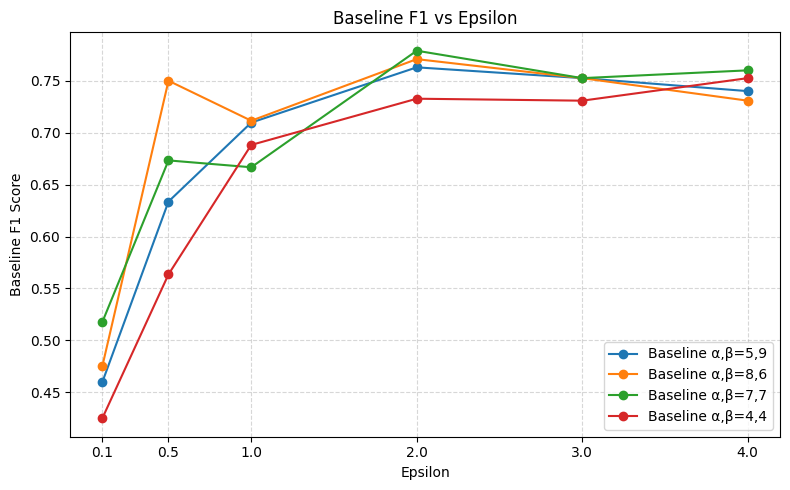

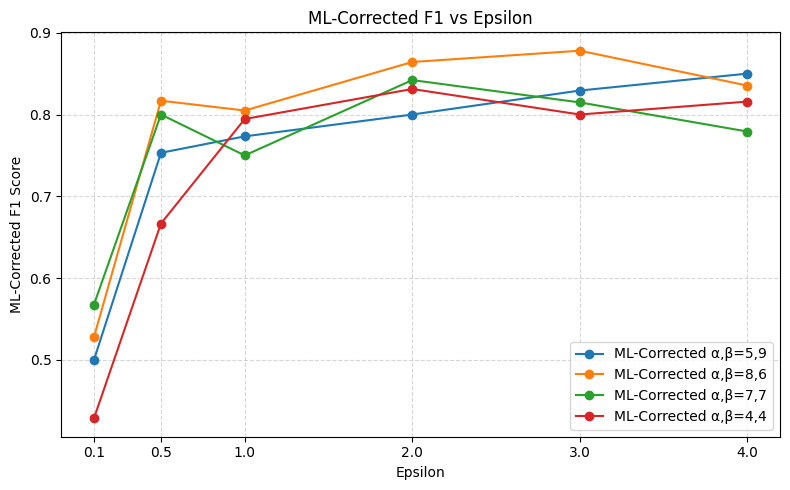

In [27]:
import matplotlib.pyplot as plt

# Epsilon values
eps = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0]

# Updated F1 score data
data = {
    "5,9": {
        "baseline": [0.4598,0.6337,0.7097,0.7629,0.7525,0.7400],
        "ml":       [0.5000,0.7532,0.7733,0.8000,0.8293,0.8500],
        "train":    [0.4982,0.7108,0.7945,0.7923,0.7859,0.8078],
        "val":      [0.6190,0.6966,0.7317,0.7000,0.7381,0.7619],
        "test":     [0.5000,0.7532,0.7733,0.8000,0.8293,0.8500],
    },
    "8,6": {
        "baseline": [0.4750,0.7500,0.7115,0.7708,0.7525,0.7308],
        "ml":       [0.5278,0.8169,0.8049,0.8642,0.8780,0.8354],
        "train":    [0.4912,0.7366,0.7817,0.7592,0.7945,0.7967],
        "val":      [0.6420,0.7342,0.7097,0.7586,0.7294,0.7561],
        "test":     [0.5278,0.8169,0.8049,0.8642,0.8780,0.8354],
    },
    "7,7": {
        "baseline": [0.5176,0.6733,0.6667,0.7789,0.7525,0.7600],
        "ml":       [0.5676,0.8000,0.7500,0.8421,0.8148,0.7792],
        "train":    [0.4560,0.6954,0.7398,0.7989,0.8056,0.8033],
        "val":      [0.5556,0.7561,0.8205,0.7381,0.7126,0.7143],
        "test":     [0.5676,0.8000,0.7500,0.8421,0.8148,0.7792],
    },
    "4,4": {
        "baseline": [0.4250,0.5636,0.6882,0.7327,0.7308,0.7525],
        "ml":       [0.4286,0.6667,0.7945,0.8312,0.8000,0.8158],
        "train":    [0.4885,0.6872,0.7494,0.7692,0.7817,0.8033],
        "val":      [0.6250,0.7317,0.7529,0.6977,0.7532,0.7407],
        "test":     [0.4286,0.6667,0.7945,0.8312,0.8000,0.8158],
    }
}

# -------------------------
# Plot 1: Train vs Val vs Test for each α,β
# -------------------------
for key in data.keys():
    plt.figure(figsize=(8,5))
    plt.plot(eps, data[key]["train"], marker='o', label="Train")
    plt.plot(eps, data[key]["val"], marker='s', label="Validation")
    plt.plot(eps, data[key]["test"], marker='^', label="Test")
    plt.xlabel("Epsilon")
    plt.ylabel("F1 Score")
    plt.title(f"Train vs Validation vs Test (α,β={key})")
    plt.xticks(eps)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# Plot 2: Baseline F1 vs Epsilon
# -------------------------
plt.figure(figsize=(8,5))
for key, val in data.items():
    plt.plot(eps, val["baseline"], marker='o', label=f"Baseline α,β={key}")
plt.xlabel("Epsilon")
plt.ylabel("Baseline F1 Score")
plt.title("Baseline F1 vs Epsilon")
plt.xticks(eps)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot 3: ML-Corrected F1 vs Epsilon
# -------------------------
plt.figure(figsize=(8,5))
for key, val in data.items():
    plt.plot(eps, val["ml"], marker='o', label=f"ML-Corrected α,β={key}")
plt.xlabel("Epsilon")
plt.ylabel("ML-Corrected F1 Score")
plt.title("ML-Corrected F1 vs Epsilon")
plt.xticks(eps)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()